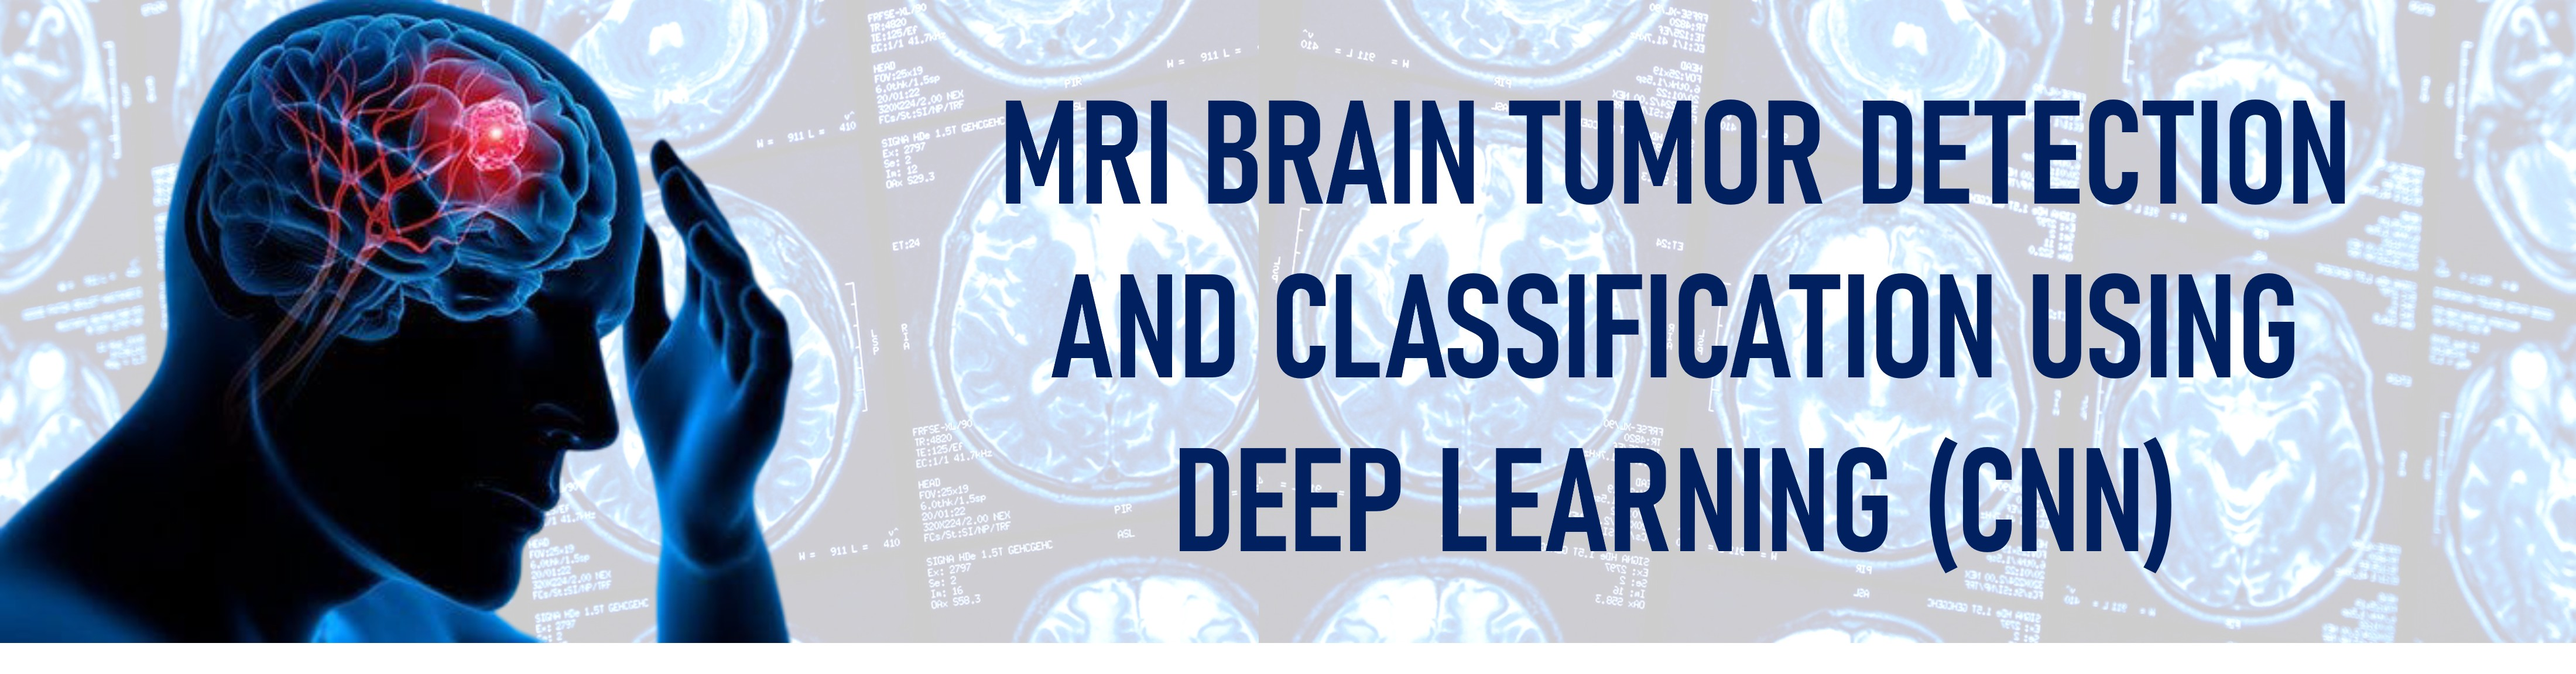

In [1]:
# Import required libraries
import os
import cv2 as cv
import numpy as np
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image

In [2]:
# Import dataset
DIR = r'C:\Users\Rav\Desktop\CNN-BTMRI-Project\dataset\mri'
CATEGORY = ['glioma', 'meningioma', 'notumor', 'pituitary']

In [3]:
%%time
# Labeling of the data
IMG_SIZE = 128

data = []

for category in CATEGORY:
    folder = os.path.join(DIR, category)
    label = CATEGORY.index(category)
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        img_arr = cv.imread(img_path)
        img_arr = cv.resize(img_arr, (IMG_SIZE, IMG_SIZE))
        data.append([img_arr, label])

CPU times: total: 5.12 s
Wall time: 5.25 s


In [4]:
# Check length data
print(len(data))

6400


In [5]:
# Creating X and y for features and labels

X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

In [6]:
# Convert X and y into array
X = np.array(X)
y = np.array(y)

In [7]:
# Feature scaling technique
X = X / 255

In [8]:
print(X.shape)

(6400, 128, 128, 3)


In [9]:
# Design CNN Model
def modelCNN():
    model = keras.Sequential([# Input layer 
                              keras.layers.Input(shape=(128, 128, 3)),
                            
                              # Convolutional layer 1
                              keras.layers.Conv2D(64, (3, 3), activation='relu'),
                              keras.layers.MaxPooling2D(2, 2),
                              
                              # Convolutional layer 2
                              keras.layers.Conv2D(64, (3, 3), activation='relu'),
                              keras.layers.MaxPooling2D(2, 2),
                            
                              # Flatten layer - Output of convolution
                              keras.layers.Flatten(),
                              
                              # Hidden layer 1
                              keras.layers.Dense(128, activation='relu'),
                              
                              # Output layer
                              keras.layers.Dense(4, activation='softmax')],
                             name="CNN-BTMRI")
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

In [10]:
model = modelCNN()
model.summary(line_length=75, positions=[0.3, 0.5, 0.65, 1.0])

Model: "CNN-BTMRI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape          ┃        Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                │ (None, 126, 126, 64)  │          1,792 │
├────────────────────────────────┼───────────────────────┼────────────────┤
│ max_pooling2d (MaxPooling2D)   │ (None, 63, 63, 64)    │              0 │
├────────────────────────────────┼───────────────────────┼────────────────┤
│ conv2d_1 (Conv2D)              │ (None, 61, 61, 64)    │         36,928 │
├────────────────────────────────┼───────────────────────┼────────────────┤
│ max_pooling2d_1 (MaxPooling2D) │ (None, 30, 30, 64)    │              0 │
├────────────────────────────────┼───────────────────────┼────────────────┤
│ flatten (Flatten)              │ (None, 57600)         │              0 │
├────────────────────────────────┼───────────────────────┼────────────────┤
│ dense (Dense)                  │ (None, 128)           │      7,372,928 │
├────────────────────────────────┼───────────────────────┼────────────────┤
│ dense_1 (Dense)                │ (None, 4)             │            516 │
└────────────────────────────────┴───────────────────────┴────────────────┘

 Total params: 7,412,164 (28.28 MB)

 Trainable params: 7,412,164 (28.28 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(X, y, epochs=5, shuffle=True)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 155ms/step - accuracy: 0.6010 - loss: 0.9414
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 33s 164ms/step - accuracy: 0.8510 - loss: 0.3588
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 38s 191ms/step - accuracy: 0.9336 - loss: 0.1785
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 195ms/step - accuracy: 0.9690 - loss: 0.0896
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 42s 197ms/step - accuracy: 0.9873 - loss: 0.0378


In [12]:
# Save a CNN model with extension .keras
model.save('btmri.keras')

In [13]:
# Predictions
CATEGORY = ['glioma', 'meningioma', 'notumor', 'pituitary']

def image(path):
    img = cv.imread(path)
    new_arr = cv.resize(img, (128, 128))
    new_arr = np.array(new_arr)
    new_arr = new_arr.reshape(1, 128, 128, 3)
    return new_arr

model = tf.keras.models.load_model('btmri.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
notumor


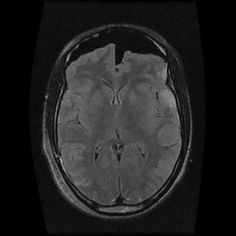

In [14]:
img = image(r'patients\notumor.jpg')
if img is not None:
    pred = model.predict(img)
    print(CATEGORY[pred.argmax()])
Image(filename='patients/notumor.jpg', width=200, height=200)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
meningioma


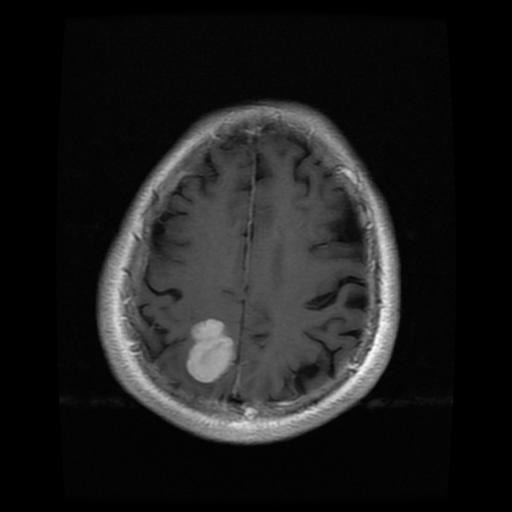

In [15]:
img = image(r'patients\meningioma.jpg')
if img is not None:
    pred = model.predict(img)
    print(CATEGORY[pred.argmax()])
Image(filename='patients/meningioma.jpg', width=200, height=200)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
pituitary


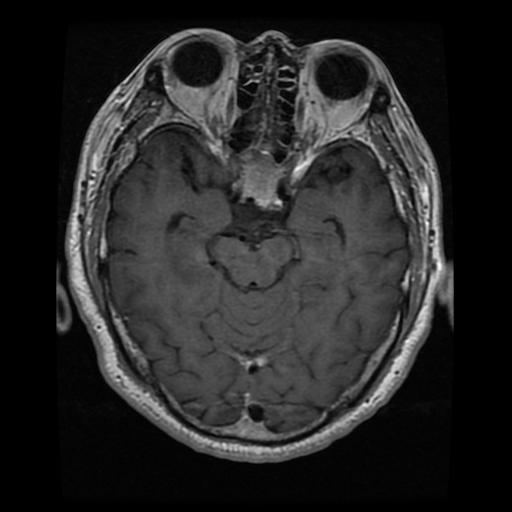

In [16]:
img = image(r'patients\pituitary.jpg')
if img is not None:
    pred = model.predict(img)
    print(CATEGORY[pred.argmax()])
Image(filename='patients/pituitary.jpg', width=200, height=200)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
glioma


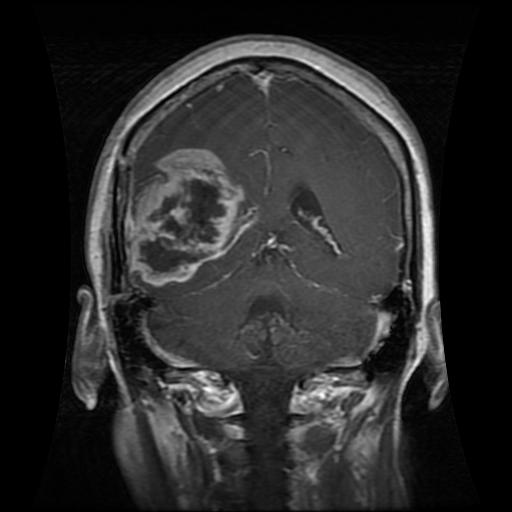

In [17]:
img = image(r'patients\glioma.jpg')
if img is not None:
    pred = model.predict(img)
    print(CATEGORY[pred.argmax()])
Image(filename='patients/glioma.jpg', width=200, height=200)